In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [30]:
nltk.download('punkt')
nltk.download('averaged_perception_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Error loading averaged_perception_tagger: Package
[nltk_data]     'averaged_perception_tagger' not found in index
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

os.listdir('/content/drive/MyDrive/Colab Notebooks')

['Untitled0.ipynb',
 'Untitled1.ipynb',
 'Copy of Hypothesis Test Practical Implementation .ipynb',
 'Untitled2.ipynb',
 'Tinanic.ipynb',
 'LLM.ipynb',
 'Untitled',
 'Untitled3.ipynb',
 'Facial-LandMark.ipynb',
 'facemask.ipynb',
 'Image-Classification.ipynb',
 'CarDD.ipynb',
 'Reviews.zip',
 'Sentiment_Analysis_Project.ipynb',
 'Copy of Sentiment_Analysis_Project.ipynb']

In [6]:
os.path.exists('/content/drive/MyDrive/Colab Notebooks/Reviews.zip')

True

In [7]:
import zipfile

zip_path = '/content/drive/MyDrive/Colab Notebooks/Reviews.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/amazon_reviews')

print("Extraction completed!")

Extraction completed!


In [8]:
import os

os.listdir('/content/amazon_reviews')

['database.sqlite', 'hashes.txt', 'Reviews.csv']

In [9]:
import pandas as pd

df = pd.read_csv('/content/amazon_reviews/Reviews.csv')

In [10]:
print("Shape:", df.shape)

Shape: (568454, 10)


In [11]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [12]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [14]:
df.shape

(568454, 10)

In [15]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [16]:
df['Score'].value_counts().sort_index()

,count
Score,
1,52268
2,29769
3,42640
4,80655
5,363122


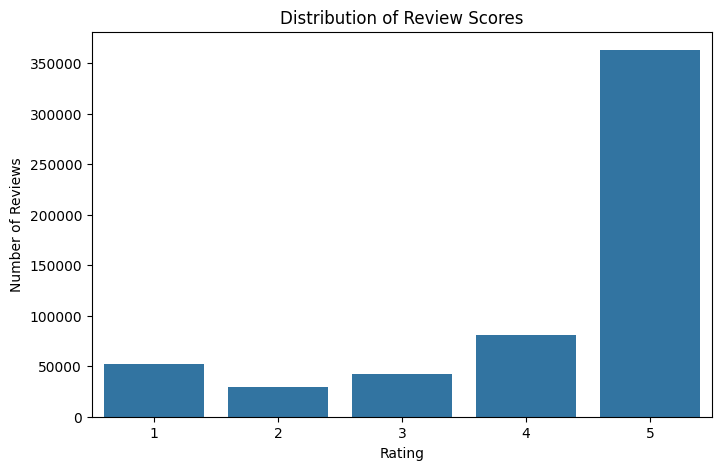

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Score')

plt.title('Distribution of Review Scores')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

In [18]:
df[['Score', 'Summary', 'Text']].head(10)

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...
5,4,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,5,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,5,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,5,Yay Barley,Right now I'm mostly just sprouting this so my...
9,5,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['Text'].duplicated().sum()

np.int64(174875)

In [21]:
df[['Score', 'Summary', 'Text']].isnull().sum()

,0
Score,0
Summary,27
Text,0


In [22]:
df = df.drop_duplicates()

In [23]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (568454, 10)


In [24]:
print("Duplicate rows remaining:", df.duplicated().sum())

Duplicate rows remaining: 0


In [25]:
df['Text'].duplicated().sum()

np.int64(174875)

In [26]:
df['Score'].value_counts().sort_index()

,count
Score,
1,52268
2,29769
3,42640
4,80655
5,363122


In [27]:
example = df['Text'][50]

print(example)

This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


In [33]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [34]:
tokens = nltk.word_tokenize(example)

print(tokens[:10])

['This', 'oatmeal', 'is', 'not', 'good', '.', 'Its', 'mushy', ',', 'soft']


In [36]:
import nltk

nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [37]:
tagged = nltk.pos_tag(tokens)

print(tagged[:10])

[('This', 'DT'), ('oatmeal', 'NN'), ('is', 'VBZ'), ('not', 'RB'), ('good', 'JJ'), ('.', '.'), ('Its', 'PRP$'), ('mushy', 'NN'), (',', ','), ('soft', 'JJ')]


In [39]:
import nltk

nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [40]:
entities = nltk.chunk.ne_chunk(tagged)

entities.pprint()

(S
  This/DT
  oatmeal/NN
  is/VBZ
  not/RB
  good/JJ
  ./.
  Its/PRP$
  mushy/NN
  ,/,
  soft/JJ
  ,/,
  I/PRP
  do/VBP
  n't/RB
  like/VB
  it/PRP
  ./.
  (ORGANIZATION Quaker/NNP Oats/NNPS)
  is/VBZ
  the/DT
  way/NN
  to/TO
  go/VB
  ./.)


In [41]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [42]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [43]:
sia.polarity_scores(example)

{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [44]:
for i in range(5):
    review = df['Text'].iloc[i]
    score = sia.polarity_scores(review)

    print("Review:", review[:100])
    print("Sentiment:", score)
    print("-" * 80)

Review: I have bought several of the Vitality canned dog food products and have found them all to be of good
Sentiment: {'neg': 0.0, 'neu': 0.695, 'pos': 0.305, 'compound': 0.9441}
--------------------------------------------------------------------------------
Review: Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. No
Sentiment: {'neg': 0.138, 'neu': 0.862, 'pos': 0.0, 'compound': -0.5664}
--------------------------------------------------------------------------------
Review: This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin wi
Sentiment: {'neg': 0.091, 'neu': 0.754, 'pos': 0.155, 'compound': 0.8265}
--------------------------------------------------------------------------------
Review: If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in
Sentiment: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
-------------------------------------

In [45]:
sample_df = df.sample(5000, random_state=42).copy()
print(sample_df.shape)

(5000, 10)


In [46]:
def rating_to_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

sample_df['actual_sentiment'] = sample_df['Score'].apply(rating_to_sentiment)

sample_df[['Score', 'actual_sentiment']].head(10)

,Score,actual_sentiment
165256,5,Positive
231465,5,Positive
427827,3,Neutral
433954,2,Negative
70260,5,Positive
49866,4,Positive
551047,5,Positive
18983,5,Positive
138968,4,Positive
36352,5,Positive


In [47]:
sample_df['vader_score'] = sample_df['Text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

In [48]:
def vader_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

sample_df['vader_sentiment'] = sample_df['vader_score'].apply(vader_sentiment)

In [49]:
sample_df[['Score', 'actual_sentiment', 'vader_score', 'vader_sentiment']].head(10)

,Score,actual_sentiment,vader_score,vader_sentiment
165256,5,Positive,0.9684,Positive
231465,5,Positive,0.7920,Positive
427827,3,Neutral,0.4588,Positive
433954,2,Negative,0.9923,Positive
70260,5,Positive,0.9421,Positive
49866,4,Positive,0.3182,Positive
551047,5,Positive,0.9445,Positive
18983,5,Positive,0.3595,Positive
138968,4,Positive,0.9740,Positive
36352,5,Positive,0.4588,Positive


In [50]:
from sklearn.metrics import accuracy_score, classification_report

vader_accuracy = accuracy_score(
    sample_df['actual_sentiment'],
    sample_df['vader_sentiment']
)

print("VADER Accuracy:", vader_accuracy)

VADER Accuracy: 0.8034


In [51]:
print(classification_report(
    sample_df['actual_sentiment'],
    sample_df['vader_sentiment']
))

              precision    recall  f1-score   support

    Negative       0.56      0.41      0.47       703
     Neutral       0.14      0.04      0.06       378
    Positive       0.85      0.95      0.89      3919

    accuracy                           0.80      5000
   macro avg       0.52      0.47      0.48      5000
weighted avg       0.75      0.80      0.77      5000



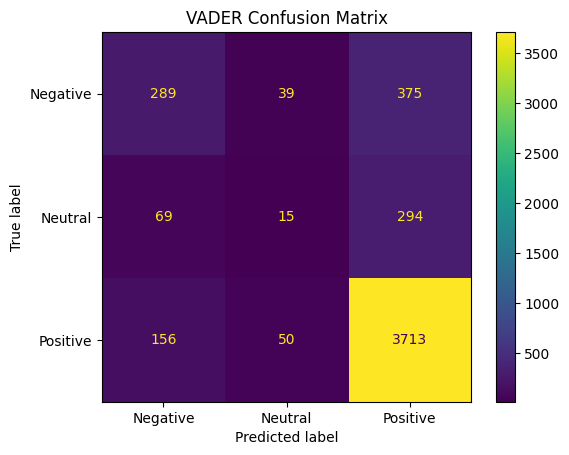

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    sample_df['actual_sentiment'],
    sample_df['vader_sentiment'],
    labels=['Negative', 'Neutral', 'Positive']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)

disp.plot()
plt.title('VADER Confusion Matrix')
plt.show()

TRANSFORMERS




In [53]:
!pip -q install transformers torch

In [54]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [55]:
from transformers import pipeline

roberta = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=0 if torch.cuda.is_available() else -1
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [56]:
roberta(example)

[{'label': 'negative', 'score': 0.9535123705863953}]

In [57]:
test_texts = sample_df['Text'].head(20).tolist()

roberta_results = roberta(test_texts)

roberta_results[:5]

[{'label': 'positive', 'score': 0.9421346783638},
 {'label': 'positive', 'score': 0.9230257868766785},
 {'label': 'negative', 'score': 0.6746856570243835},
 {'label': 'neutral', 'score': 0.6439717411994934},
 {'label': 'positive', 'score': 0.9564847946166992}]

In [58]:
texts = sample_df['Text'].astype(str).tolist()

roberta_results = roberta(
    texts,
    batch_size=32,
    truncation=True,
    max_length=256
)

In [59]:
sample_df['roberta_sentiment'] = [
    result['label'].capitalize()
    for result in roberta_results
]

In [60]:
sample_df[['Text', 'actual_sentiment', 'roberta_sentiment']].head(10)

,Text,actual_sentiment,roberta_sentiment
165256,Having tried a couple of other brands of glute...,Positive,Positive
231465,My cat loves these treats. If ever I can't fin...,Positive,Positive
427827,A little less than I expected. It tends to ha...,Neutral,Negative
433954,"First there was Frosted Mini-Wheats, in origin...",Negative,Neutral
70260,and I want to congratulate the graphic artist ...,Positive,Positive
49866,Please add more Pineapple flavor to your packa...,Positive,Positive
551047,I absolutely love Yorkshire tea and am so glad...,Positive,Positive
18983,I have such a hard time finding loose tea loca...,Positive,Positive
138968,"Previously, I've attempted a recipe with white...",Positive,Neutral
36352,I make pancakes or waffles every Saturday morn...,Positive,Positive


In [61]:
roberta_accuracy = accuracy_score(
    sample_df['actual_sentiment'],
    sample_df['roberta_sentiment']
)

print("RoBERTa Accuracy:", roberta_accuracy)

RoBERTa Accuracy: 0.8138


In [62]:
print(classification_report(
    sample_df['actual_sentiment'],
    sample_df['roberta_sentiment']
))

              precision    recall  f1-score   support

    Negative       0.62      0.77      0.69       703
     Neutral       0.16      0.17      0.16       378
    Positive       0.93      0.88      0.91      3919

    accuracy                           0.81      5000
   macro avg       0.57      0.61      0.59      5000
weighted avg       0.83      0.81      0.82      5000



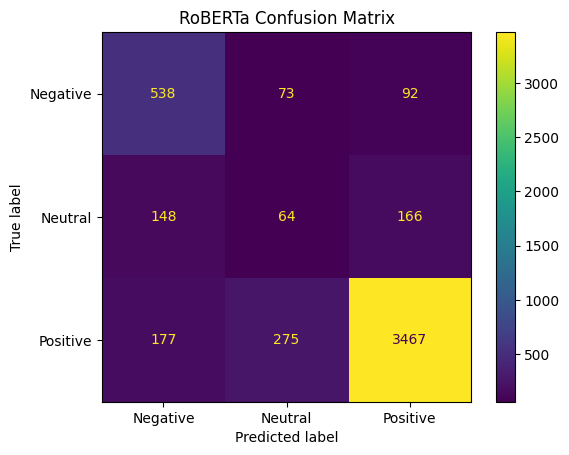

In [63]:
cm = confusion_matrix(
    sample_df['actual_sentiment'],
    sample_df['roberta_sentiment'],
    labels=['Negative', 'Neutral', 'Positive']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)

disp.plot()
plt.title('RoBERTa Confusion Matrix')
plt.show()

In [64]:
comparison = pd.DataFrame({
    'Model': ['VADER', 'RoBERTa'],
    'Accuracy': [vader_accuracy, roberta_accuracy]
})

comparison

,Model,Accuracy
0,VADER,0.8034
1,RoBERTa,0.8138


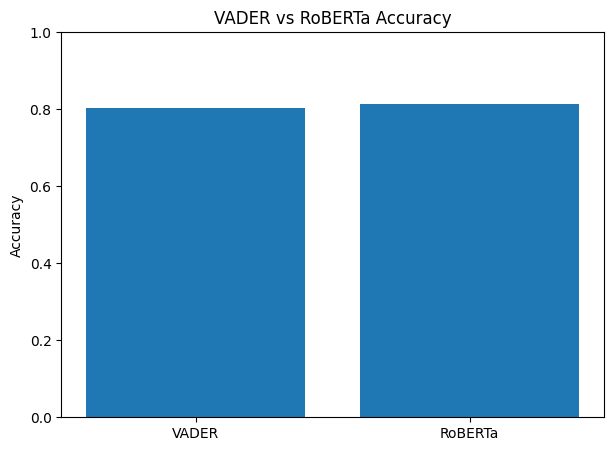

In [65]:
plt.figure(figsize=(7,5))

plt.bar(comparison['Model'], comparison['Accuracy'])

plt.title('VADER vs RoBERTa Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.show()

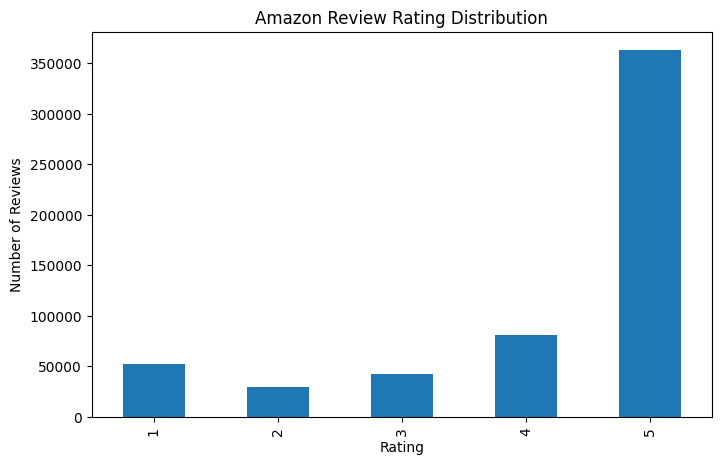

In [66]:
plt.figure(figsize=(8,5))

df['Score'].value_counts().sort_index().plot(kind='bar')

plt.title('Amazon Review Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

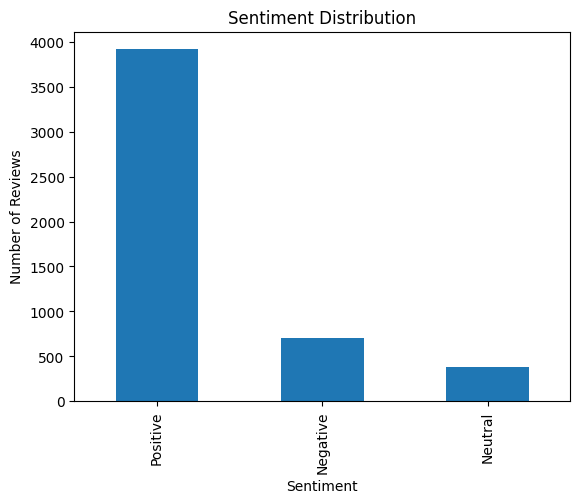

In [67]:
sample_df['actual_sentiment'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [68]:
print("Average Rating:", round(df['Score'].mean(), 2))

Average Rating: 4.18


In [69]:
df['helpfulness_ratio'] = (
    df['HelpfulnessNumerator'] /
    df['HelpfulnessDenominator'].replace(0, 1)
)

In [70]:
df[['Score', 'HelpfulnessNumerator',
   'HelpfulnessDenominator',
   'helpfulness_ratio']].head()

,Score,HelpfulnessNumerator,HelpfulnessDenominator,helpfulness_ratio
0,5,1,1,1.0
1,1,0,0,0.0
2,4,1,1,1.0
3,2,3,3,1.0
4,5,0,0,0.0


In [71]:
top_helpful = df.sort_values(
    'helpfulness_ratio',
    ascending=False
).head(10)

top_helpful[['Score', 'Summary', 'Text', 'helpfulness_ratio']]

,Score,Summary,Text,helpfulness_ratio
64421,5,Bought This for My Son at College,My son loves spaghetti so I didn't hesitate or...,3.0
44736,4,Pure cocoa taste with crunchy almonds inside,It was almost a 'love at first bite' - the per...,1.5
408044,5,Great tasting hot chocolate,I love Stephen's Gourmet Hot chocolate. It ar...,1.0
408094,5,Premium Coffee,"This is some of the richest, bold and best tas...",1.0
408096,5,A Kid's Dream Food,I bought this and two other Popin Cookin items...,1.0
408097,5,Really Fun,Great fun and the flavors are ok. The best pa...,1.0
122245,4,Tasty oats!,"I don't know why, but steel-cut oats make much...",1.0
408092,5,Great coffee!,"My husband and I love our coffee, and we love ...",1.0
408093,5,Wonderful,I have been drinking this coffee for a few yea...,1.0
122246,5,Great taste and texture!,I really like these oats. I cook one cup (dry)...,1.0


In [72]:
!pip -q install wordcloud

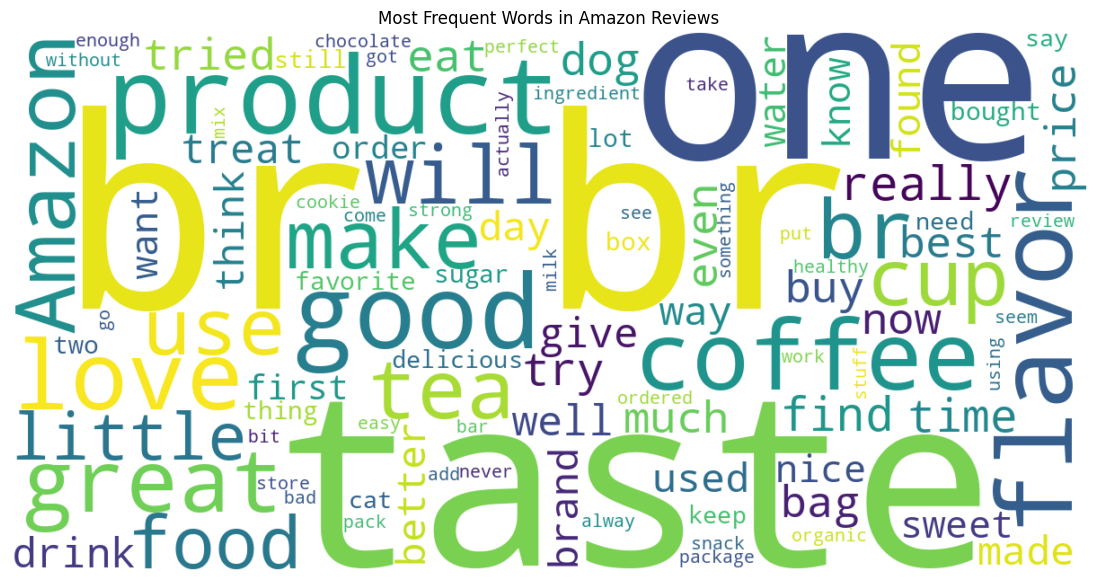

In [73]:
from wordcloud import WordCloud

text = ' '.join(sample_df['Text'].astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Amazon Reviews')
plt.show()

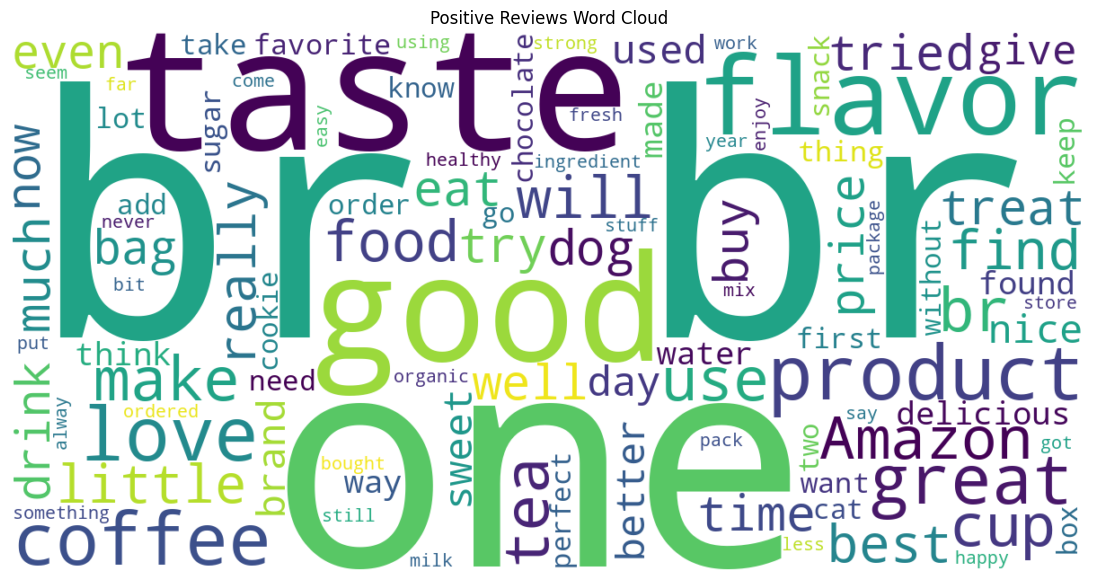

In [74]:
positive_text = ' '.join(
    sample_df.loc[
        sample_df['actual_sentiment'] == 'Positive',
        'Text'
    ].astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(positive_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews Word Cloud')
plt.show()

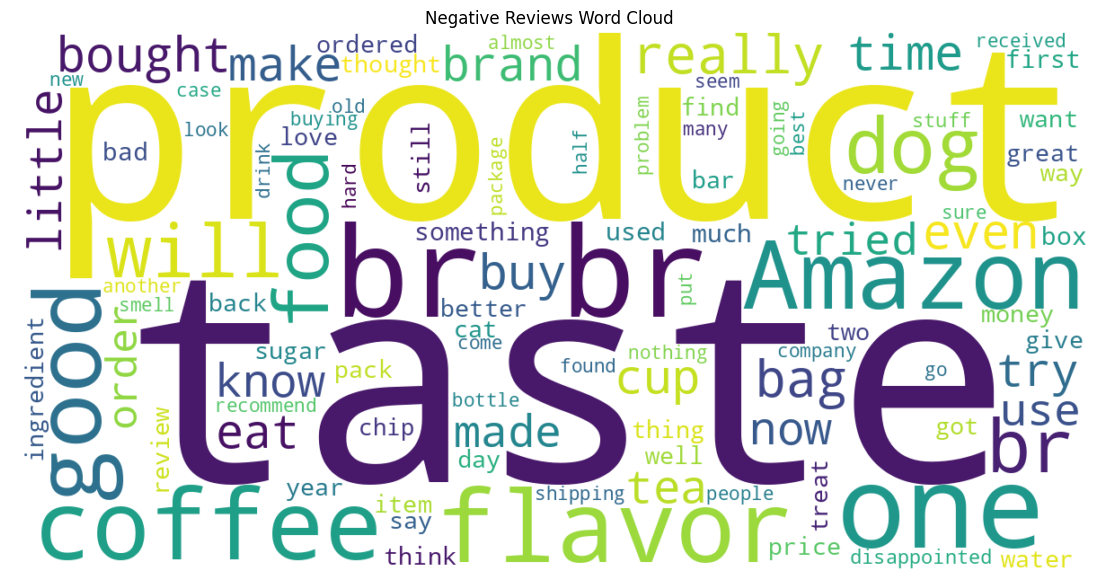

In [75]:
negative_text = ' '.join(
    sample_df.loc[
        sample_df['actual_sentiment'] == 'Negative',
        'Text'
    ].astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews Word Cloud')
plt.show()

In [76]:
new_review = input("Enter an Amazon food review: ")

vader_result = sia.polarity_scores(new_review)

roberta_result = roberta(new_review)

print("\nVADER:")
print(vader_result)

print("\nRoBERTa:")
print(roberta_result)

Enter an Amazon food review: The food was amazing and arrived quickly. I really enjoyed it.

VADER:
{'neg': 0.0, 'neu': 0.52, 'pos': 0.48, 'compound': 0.8122}

RoBERTa:
[{'label': 'positive', 'score': 0.9894730448722839}]


In [77]:
sample_df.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/amazon_sentiment_results.csv',
    index=False
)

print("Results saved successfully!")

Results saved successfully!
